# Radar FMCW #


_Mini-projet Traitement du Signal 2025-26_

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
from mpl_toolkits.mplot3d import Axes3D

%matplotlib ipympl

## I. Principe du radar FMCW ##


Pour prouver qu'on peut considérer la distance r(t) comme constante durant l'émission des signaux, il faut montrer que le déplacement maximal de la cible sur le temps de mesure est négligeable devant la résolution du radar. On obtient donc :
$\newline$
$$ \Delta r_{max}(T_{chirp}) = v_{max}.T_{chirp} = 4.69.10^{-4}~m$$
De même : 
$$ \Delta r_{max}(N_{chirp}T_{chirp}) = v_{max}.N_{chirp}T_{chirp} = 3 ~cm$$
$\newline$
Il faut donc maintenant trouver la résolution du radar. Comme on envoie un signal tous les $T_{chirp}$ on a donc $\Delta f_{min}=\frac{1}{T_{chirp}}$.
$\newline$ 
Or pour mesurer la distance r, le radar utilise une variation de fréquence (c'est le rôle joué par $\sigma(t)$). La variation de fréquence minimale est $\Delta f_{min}$ et elle est égale à : 
$$ pente~de~la~variation~de~fréquence ~.~ temps~de~voyage~du~signal = \frac{B}{T_{chirp}}.\frac{2\Delta r_{min}}{c}$$
D'où : $$\Delta r_{min} = \frac{c}{2B}$$
L'application numérique donne : $\Delta r_{min} = 1~m$
$\newline$ 
On a bien : $$\Delta r_{max}(T_{chirp})\ll\Delta r_{max}(N_{chirp}T_{chirp})\ll\Delta r_{min}$$
On peut donc considérer la distance comme constante durant la durée de la salve de chirp.

## II. Démodulation et bande de base ##
### A. Démodulation du signal reçu ###

Le signal reçu, conformément à l'énoncé est : $$x_{R}(t) = a(r(t))cos(\Phi_{R}(t))$$


Une fois le LNA passé : $$x_{R}(t) = k'a(r(t))cos(\Phi_{R}(t))$$


Dans le cas où on multiplie par un cosinus :  $$x_{R}(t) = k'a(r(t))cos(\Phi_{R}(t))cos(\Phi_{T}(t))$$


Les formules de trigonométrie nous donnent que :$$x_{R}(t) = k'a(r(t))\frac{1}{2}(cos(\Phi_{R}(t)-\Phi_{T}(t))+cos(\Phi_{T}(t)\Phi_{R}(t)))$$


De manière analogue dans le cas du sinus : $$x_{R}(t) = k'a(r(t))\frac{1}{2}(sin(\Phi_{R}(t)-\Phi_{T}(t))+sin(\Phi_{T}(t)+\Phi_{R}(t)))$$


On remarque que : $\Phi_{R}(t)+\Phi_{T}(t) \approx 2f_{c} = 154~GHz$ alors que $\Phi_{T}(t)-\Phi_{R}(t) \approx 1~Hz $ (en ordre de grandeur). Or la dernière étape est le bloc IF qui est un passe bas, le signal de fréquence $\Phi_{R}(t)+\Phi_{T}(t)$ est donc coupé alors que celui de fréquence $\Phi_{T}(t)-\Phi_{R}(t)$ passe sans problème. 


En posant $k = \frac{k'}{2}$ on trouve : $$x_{R}(t) = ka(r(t))(cos(\Phi_{T}(t)-\Phi_{R}(t)))$$
$$x_{R}(t) = ka(r(t))(sin(\Phi_{T}(t)-\Phi_{R}(t)))$$

Ainsi on doit choisir $f_{coupure}$ tel que $ \Phi_{T}(t)-\Phi_{R}(t)\ll f_{coupure}\ll \Phi_{R}(t)+\Phi_{T}(t)$, de sorte à être sur que le signal de haute fréquence soit supprimé mais que celui de basse fréquence passe tout le temps. Donc prendre $f_{coupure} = 20~GHz$ devrait faire l'affaire. 

### B. Démodulation en bande de base ###

On a en effectuant le rapport des signaux : $$ \frac{\tilde x_{R}(t)}{\tilde x_{T}(t)} = a(r(t)) e^{j(\Phi_{R}(t)-\Phi_{T}(t))}$$


On retrouve bien la différence $\Phi_{R}(t)-\Phi_{T}(t)$ souhaitée dans l'exponentielle complexe. Pour la suite il suffit de prendre la partie réelle pour le cosinus et la partie imaginaire pour le sinus puis les multiplier par $ k$.


En travaillant en bande de base, il est très facile de trouver la différence $\Phi_{R}(t)-\Phi_{T}(t)$ qui nous permettra par la suite de détreminer la vitesse de la cible (un rapport des signaux suffit) alors que le protocole de la partie II.A est long, moins évident à mettre en place et on risque potentiellement de perdre des données lors du filtrage. 

De manière absolue on perd de l'information car on filtre une partie du signal. Mais la partie filtrée ne comporte pas d'information utile à notre problème. Ce qui nous intéresse est la différence des phases $\Phi_{T}(t)-\Phi_{R}(t)$ et cette partie est bien laissée intacte. Donc du point de vue du traitement du signal aucune information n'est perdue. 


## III. Examen des signaux fournis ###



In [2]:
data = sio.loadmat('radar.mat')
xt = data['xt']
xr = data['xr']

Un chirp dure $T_{chirp}= \frac{22}{3} \mu s$. Or dans la taille de 'xt' est de 8800 points. Donc la fréquence d'échantillonage est :
$$ f_{ech} = \frac{8800}{T_{chirp}} = 1.2 ~GHz $$

/opt/anaconda3/envs/io/lib/python3.13/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/anaconda3/envs/io/lib/python3.13/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


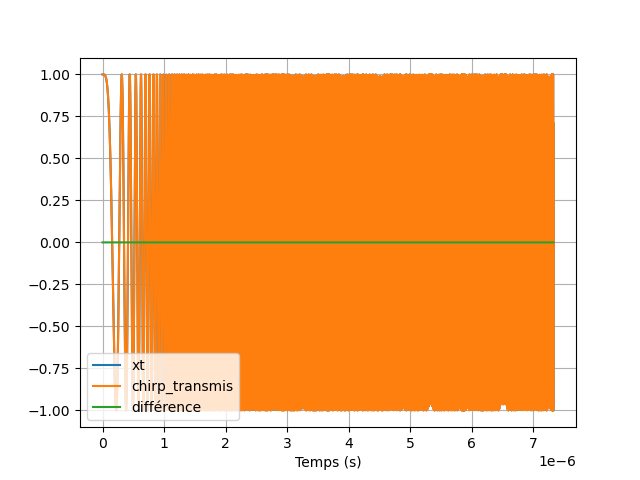

In [3]:
T_chirp= (22/3)*1e-6
N_chirp = 64
B = 150e6
beta = 2*np.pi*(B/T_chirp)
fc = 77e9
fech = 1.2e9


def sigma(t):
    return t%T_chirp

def phi_t(t):
    return 2*np.pi*fc*t + (beta/2)*sigma(t)**2

def chirp_transmis(t):
    return np.exp(1j*phi_t(t)-1j*2*np.pi*fc*t )

# Le code ci-dessus n'est pas le plus efficace, mais il est plus facile à comprendre et permet de montrer notre compréhension du problème.
# On aurait pu considérer la fonction ci dessous pour plus de simplicité :
# def chirp_transmis(t):
#    return np.exp(1j*(beta/2)*(t%T_chirp)**2)

time = np.linspace(0,T_chirp, len(xt), endpoint=False)
fig1, ax1 = plt.subplots()
ax1.plot(time, xt, label='xt')
ax1.plot(time, chirp_transmis(time), label='chirp_transmis')
plt.plot(time, np.abs(xt.flatten() - chirp_transmis(time)), label='différence')
plt.xlabel("Temps (s)")
plt.grid(True)
plt.legend()    
plt.show()

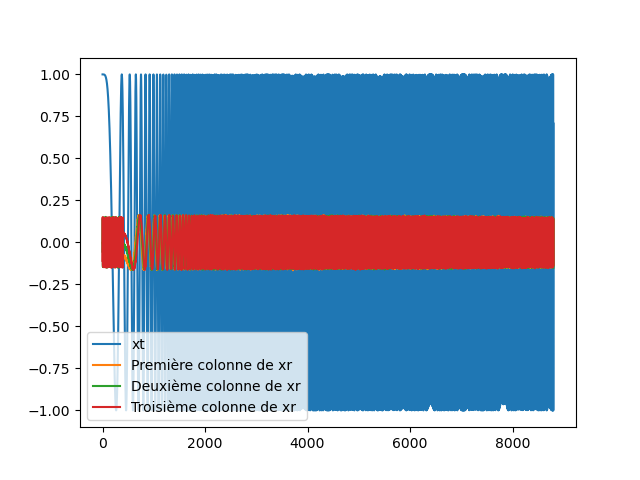

In [4]:
fig2, ax2 = plt.subplots()
ax2.plot(xt, label='xt')
ax2.plot(xr[:,0]*1000, label='Première colonne de xr')
ax2.plot(xr[:,1]*1000, label='Deuxième colonne de xr')
ax2.plot(xr[:,2]*1000, label='Troisième colonne de xr')
ax2.legend()

On multplie par 1000 l'amplitudes 3 premières colonnes de xr pour mieux comparer leurs formes à celle de xt. On remarque en effet que xr a un retard de 400 points environ sur xt et que la forme est cependant bien identique pour $N\geq 398$. O note aussi que le dépahsage augmente avec l'indice de la colonne de xr (la troisième colonne de xr est plus retardé que la première).


Sur le graphique ci-dessous, nous avons supprimé le retard initial de 398 points pour aligner les signaux et mieux comparer leur forme et observer le déphasage. 

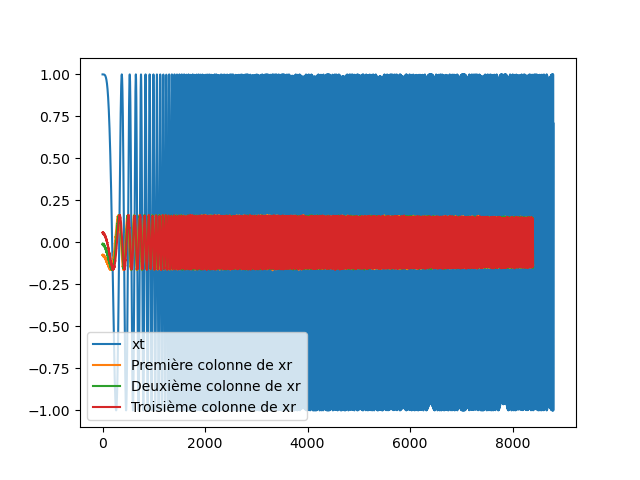

In [5]:
fig3, ax3 = plt.subplots()
ax3.plot(xt, label='xt')
ax3.plot(xr[398:,0]*1000, label='Première colonne de xr')
ax3.plot(xr[398:,1]*1000, label='Deuxième colonne de xr')
ax3.plot(xr[398:,2]*1000, label='Troisième colonne de xr')
ax3.legend()

Comme mentionné ci-dessus le signal xr commence avec un retard de 398 points. Ce décalage correspond au temps que le signal met à parcourir l'aller retour entre la voiture et le radar. Or nous savons que la fréquence d'échantillonage est $f_{ech}= 1.2 ~GHz $ donc le retard $\Delta t$ vaut : 
$$ \Delta t = \frac{398}{f_{ech}} = 0.33 ~\mu s$$
Donc de manière analogue à la partie 1 : $$ c = \frac{2r(t)}{\Delta t}$$
D'où : $$r(t) = \frac{\Delta t. c}{2} = 49.75~m $$

Le résultat semble assez cohérent car selon l'énoncé la distance maximale d'une cible est de 200 m. Selon la question 1, la précision du radar est de l'odre du mètre, on peut donc arrondir le résulat à : $ r = 50~m$

## IV. Estimation de la distance r ###


Pour la démodulation en bande de base on se reporte à la partie $II.B$. On avait trouvé : $$ \frac{\tilde x_{R}(t)}{\tilde x_{T}(t)} = a(r(t)) e^{j(\Phi_{R}(t)-\Phi_{T}(t))}$$
Pour construire xrd on doit donc "diviser" la matrice xr par xt pour toutes les colonnes. Mais comme ici xt est juste une exponentielle complexe, il suffit de multiplier par son conjuguée pour avoir le même résultat (cela sera plus efficace pour construire xrd après): 
$$\frac{\tilde x_{R}(t)}{\tilde x_{T}(t)} = \tilde x_{R}(t) \underline {\tilde x_{T}}(t) $$

(8800, 64)


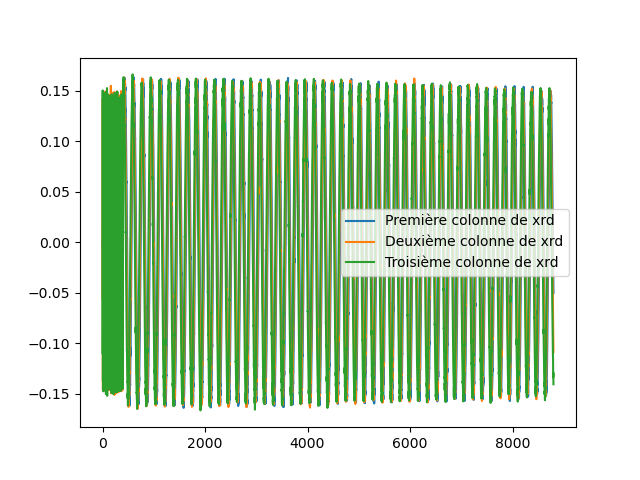

In [6]:
xrd = xr*np.conj(xt)
# En procédant ainsi on évite l'utilisation d'une boucle for couteuse et lente pour diviser chaque colone de xr par xt.

print(xrd.shape)

fig4, ax4 = plt.subplots()
ax4.plot(xrd[:,0]*1000, label='Première colonne de xrd')
ax4.plot(xrd[:,1]*1000, label='Deuxième colonne de xrd')
ax4.plot(xrd[:,2]*1000, label='Troisième colonne de xrd')
ax4.legend()

Comme précédemment le déphasage augmente avec l'indice de la colonne.

La sinusoide ci-dessus a une pulsation $\Phi_{R}(t)-\Phi_{T}(t)$, calculons donc cette différence $\Delta\Phi$ :

$$ \Delta\Phi = \omega_{c}t - \omega_{c}\frac{2r(t)}{c}+\frac{\beta}{2}\sigma^2(t-\frac{2r(t)}{c}) -\omega_{c}t - \frac{\beta}{2}\sigma^2(t) = -\omega_{c}\frac{2r(t)}{c} + \frac{\beta}{2}(\sigma^2(t-\frac{2r(t)}{c})-\sigma^2(t))$$

Or pour une seule chirp $\sigma(t) = t$ : $$\Delta\Phi = -\omega_{c}\frac{2r(t)}{c} + \frac{\beta}{2}((t-\frac{2r(t)}{c})^2-t^2)$$

(le principe serait le même avec plusieurs chirps : $\sigma(t)=\tilde{t}$ et $\sigma(t-\frac{2r(t)}{c}) = \tilde{t}-\frac{2r(t)}{c}$)

On obtient alors : $$ \Delta\Phi = -\omega_{c}\frac{2r(t)}{c} + 2\beta(\frac{r(t)^2}{c^2}-\frac{r(t)}{c}t)$$

D'où : $$ \Delta\Phi = -2\beta\frac{r(t)}{c}t + cste$$

Ainsi la sinusoide a bien une pulsation d'environ $\omega_{b} = 2\beta\frac{r(t)}{c}$.Donc $r(t) = \frac{\omega_{b}c}{2\beta}$


Pour obtenir la valeur de $\omega_{b}$ on va réaliser la transformée de Fourier de la première colonne de xrd.

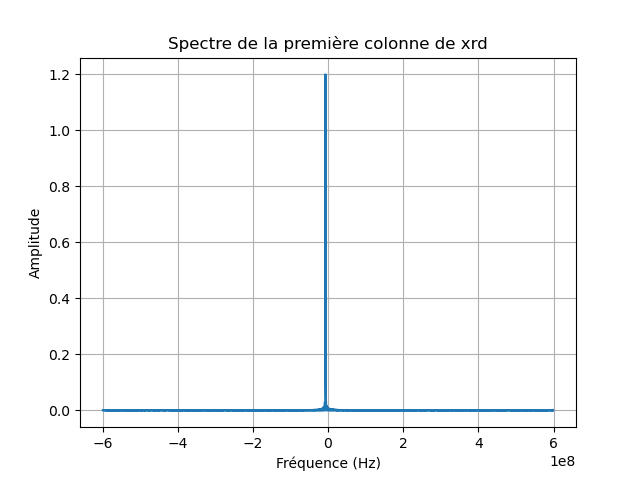

In [7]:
signal1 = np.fft.fft(xrd[:,0])
frequencies1 = np.fft.fftfreq(len(signal1), d=1/fech)
plt.figure()
plt.plot(frequencies1, np.abs(signal1))
plt.xlabel('Fréquence (Hz)')
plt.ylabel('Amplitude')
plt.title('Spectre de la première colonne de xrd')
plt.grid()
plt.show()


On trouve une fréquence principale à $f_{b} = 6.8~MHz$ donc $\omega_{b} = 42.839~10^6~s^{-1}$

Donc on trouve : $$ r(t) = 50.0~m$$ 

A 50 cm près on retrouve le résultat de la partie III, mais comme le radar a une précision de l'ordre du mètre on peut dire que les deux résultats de r(t) sont égaux. 

In [8]:
#B = 150*10**6
#T_chirp = (22/3)*10**(-6)
#c = 3*10**8
#fs =1.2*10**9

#N_fft = xr.shape[0]
#N_cols = xr.shape[1]     
#Xrd = np.fft.fft(xrd, n=N_fft, axis=0)   # FFT sur chaque colonne
#Xrd = Xrd[:N_fft//2, :]       # on garde les fréquences positives
#freqs = np.fft.fftfreq(N_fft, d=1/fs)[:N_fft//2]         # fréquences positives (Hz)
#distances = (freqs *T_chirp* c) / (2*B)           # conversion en mètres
#indices_colonnes = np.arange(N_cols)

#D, C = np.meshgrid(distances, indices_colonnes) 
#Z = np.abs(Xrd).T   # module de la FFT, transposée pour avoir (N_cols x N_fft//2)

# Affichage 3D
#fig5 = plt.figure(figsize=(12, 7))
#ax5 = fig5.add_subplot(111, projection='3d')
#ax5.plot_surface(D, C, Z, cmap='viridis', edgecolor='none')
#ax5.set_xlabel('Distance r (m)')
#ax5.set_ylabel('Indice chirp')
#ax5.set_zlabel('Amplitude de la FFT')
#ax5.set_title('FFT de xrd colonne par colonne')
#plt.tight_layout()
#plt.show()



# Attention je sais pas pourquoi mais on trouve 100 m au lieu de 50 #

## V. Estimation de la vitesse radiale $\overset{.}{r}$ ##


La durée totale de chirps est de $N_{chirp}T_{chirp} = 0.469~ms$. On va considérer une variation de 1 km/h comme précision souhaitée du radar (ce qui semble plutôt cohérent pour l'application automobile). L'accélération nécessaire pour augmenter sa vitesse d'un kilomètre par heure sur le temps de la salve de chirp est :
$$ a=\frac{v}{dt}=\frac{3.6}{0.469.10^{-3}} = 7 676~m.s^{-2}$$

Meme les meilleures voitures n'ont pas une telle capacité d'accélération (782 g). On peut donc considérer que la vitesse radiale est constante durant toute la durée de la salve de chirps. 


Comme on peut considérer $\overset{.}{r}(t)$ comme constant sur une salve de chirps on a que $r(t) = r_{0}+\overset{.}{r}t$. De manière analogue à la partie précédente on trouve que : $$ \Delta\Phi = -\omega_{c}\frac{2r(t)}{c} + \frac{\beta}{2}(\sigma^2(t-\frac{2r(t)}{c})-\sigma^2(t))$$ Or sur une même ligne le deuxième terme est le même pour toutes les valeurs de la ligne car on ajoute $T_{chirp} à chaque nouvelle colonne. Donc la différence de phase entre deux valeurs consécutives d'une même ligne est :
$$ \Delta\Phi_{1}-\Delta\Phi_{2} = -\omega_{c}\frac{2r(t)}{c}+\omega_{c}\frac{2r(t+T_{chirp})}{c} = -\omega_{c}\frac{2(r_{0}+\overset{.}{r}t)}{c}+\omega_{c}\frac{2(r_{0}+\overset{.}{r}(t+T_{chirp})))}{c} = \omega_{c}\frac{2\overset{.}{r}T_{chirp}}{c}$$

Or on a que : $$\omega = 2\pi \cdot f = 2\pi \cdot \frac{\Delta \phi}{2\pi \Delta t} = \frac{\Delta \phi}{\Delta t}$$

Ici $\Delta t = T_{chirp}$ et $\Delta \phi = \Delta\Phi_{1}-\Delta\Phi_{2}$ , d'où : $$ \omega = \omega_{c}\frac{2\overset{.}{r}}{c}$$

/opt/anaconda3/envs/io/lib/python3.13/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/anaconda3/envs/io/lib/python3.13/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


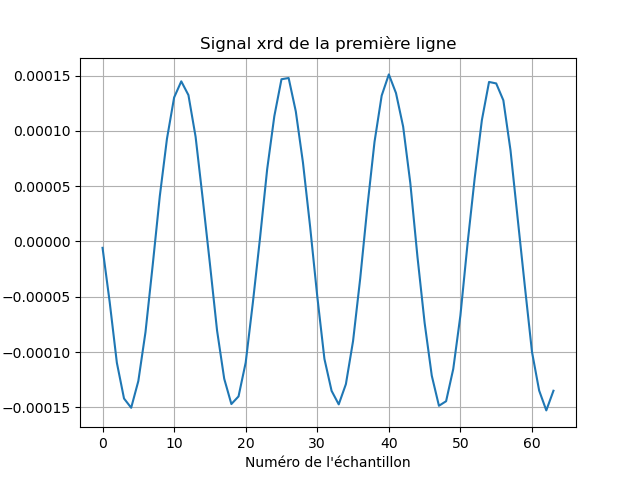

In [18]:
plt.close('all')
ligne = xrd[0, :]
t = np.arange(len(ligne))
plt.plot(t, ligne)
plt.xlabel("Numéro de l'échantillon")
plt.ylabel('Amplitude')
plt.title('Signal xrd de la première ligne')
plt.grid()
plt.show()

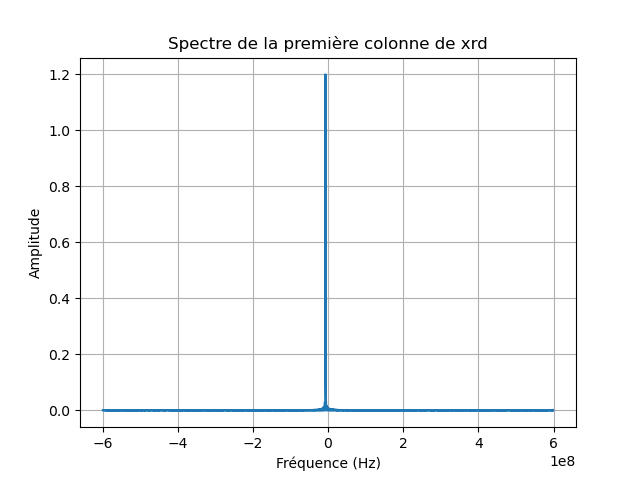

In [19]:
signal2 = np.fft.fft(xrd[:,0])
frequencies2 = np.fft.fftfreq(len(signal2), d=1/fech)
plt.figure()
plt.plot(frequencies2, np.abs(signal2))
plt.xlabel('Fréquence (Hz)')
plt.ylabel('Amplitude')
plt.title('Spectre de la première colonne de xrd')
plt.grid()
plt.show()

On trouve $f=6.8~MHz$ d'où : $$\overset{.}{r} = \frac{\omega c}{2\omega_{c}} =\frac{f c}{2 f_{c}} = $$

il y a un problème je trouve des vitesse aberrantes. Je crois que ça vient de la fft, on est tout le temps a la même frequence alors qu'il devrait y avoir un décalage.

## VI. Pour aller plus loin ##